                                                 text  Cluster
0            Hatsukoi Monogatari (Japan) (Rev 1) 初恋物语        4
1   Death Bringer - The Knight of Darkness (Japan)...        2
2   Cosmic Fantasy 2 - Bouken Shounen Ban (Japan) ...        2
3                    Lady Phantom (Japan) (FABT) 幻影女郎        2
4                                   Babel (Japan) 通天塔        2
5   Cosmic Fantasy 3 - Bouken Shounen Rei (Japan) ...        2
6                                     Xak (Japan) XAK        2
7   Cosmic Fantasy - Bouken Shounen Yuu (Japan) (A...        2
8   Gyuwambler Jiko Chuushinha - Mahjong Puzzle Co...        2
9   Alnam no Kiba - Juuzoku Juuni Shinto Densetsu ...        3
10                      Princess Minerva (Japan) 智王传说        2
11         Sotsugyou II - Neo Generation (Japan) 卒业 2        2
12  Where in the World Is Carmen Sandiego (Japan) ...        2
13  Cyber City Oedo 808 - Kemono no Alignment (Jap...        2
14                      ROM ROM Stadium (Japan) 棒球体育场  

/var/folders/88/w4w1n8l12kd_z42_6mrnndmw0000gn/T/ipykernel_6052/3570138217.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = df.select_dtypes(include="object").columns


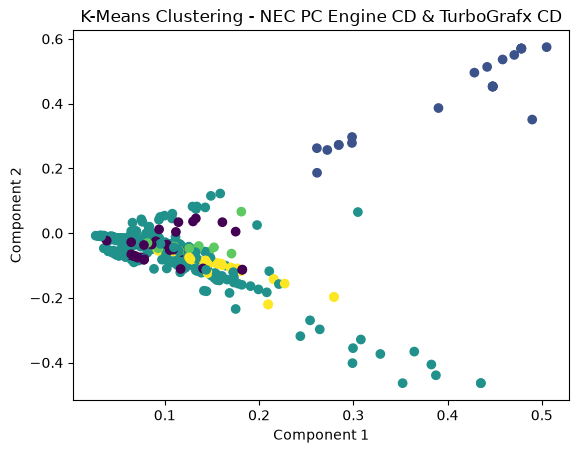


Saved successfully!


In [1]:
# 1. Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

# 2. Load dataset
df = pd.read_csv("NEC - PC Engine CD & TurboGrafx CD.csv")

# 3. Combine text columns
text_cols = df.select_dtypes(include="object").columns
df["text"] = df[text_cols].fillna("").astype(str).agg(" ".join, axis=1)

# 4. NLP + TF-IDF
tfidf = TfidfVectorizer(stop_words="english", max_features=3000)
X = tfidf.fit_transform(df["text"])

# 5. K-Means
k = 5
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X)

# 6. Show results
print(df[["text", "Cluster"]].head(20))

# 7. Cluster sizes
print("\nCluster Sizes:")
print(df["Cluster"].value_counts().sort_index())

# 8. Visualise clusters
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=2, random_state=42)
X_2D = svd.fit_transform(X)

plt.scatter(X_2D[:, 0], X_2D[:, 1], c=df["Cluster"])
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.title("K-Means Clustering - NEC PC Engine CD & TurboGrafx CD")
plt.show()

# 9. Save results
df.to_csv("NEC_PC_Engine_TurboGrafx_CD_Clusters.csv", index=False)
print("\nSaved successfully!")